# **Модуль А:** Анализ и предобработка данных

## Подготовка рабочего пространства

### Импортирование библиотек

In [3]:
# для работы с датафреймами
import pandas as pd

# для визуализации результатов
import matplotlib.pyplot as plt

# для работы с массивами
import numpy as np

# для преобразования текста
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize

# для работы со строками
import string

# вспомогательные функции
from function import *

# для работы с датасетами
from datasets import Dataset, DatasetDict

# для обработки текста
from pymystem3 import Mystem

# токенизатор
from transformers import T5Tokenizer

### Настройка переменных и загрузка дополнительных параметров

In [4]:
# применяем стиль для графиков
plt.style.use('dark_background')

In [5]:
# скачиваем стоп-слова для русского языка
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alzot\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Вспомогательные функции

Все функции реализованны в файле `function.py`

```py
# функция для чистки стоп слов
def clean_text(text: str, stop_words: set):
    '''
    Функция для чистки текста от стоп слов
        Args:
            - test (str): текст, который нужно почистить от стоп слов
            - stop_words (set): множество стоп слов
        Returns:
            - отфильтрованный текст (str)
    '''
    # создаем список слов используя split()
    words = text.split()
    # фильтруем слова используя заданное множество
    filtered_words = [word for word in words if word.lower() not in stop_words]
    # возвращаем почищенный текст
    return ' '.join(filtered_words)
```

```py
# функция для преобразования формата датасета 
def reorganize_dataset(dataset_path: str):
    '''
    Функция, преобразующая папки в датасет (DataseDict)
    Args:
        - dataset_path (str): путь к папке с данными в строковом формате
    Returns:
        - DatasetDict()
    '''

    # список для всех примеров
    samples = []
    # собираем все примеры
    for folder in os.listdir(dataset_path):
        # путь к папке
        folder_path = os.path.join(dataset_path, folder)
        # проверяем, папка ли это
        if os.path.isdir(folder_path):
            # получаем путь к тексту и аннотации
            text_path = os.path.join(folder_path, 'text.txt')
            annotation_path = os.path.join(folder_path, 'annotation.txt')
            tags_path = os.path.join(folder_path, 'tags.txt')
            

            # проверяем, существуют ли эти файлы
            if os.path.exists(text_path) and os.path.exists(annotation_path):
                # открываем и читаем файл с текстом
                with open(text_path, 'r', encoding='utf-8') as f:
                    text = f.read().strip()

                # открываем и читаем файл с аннотацией
                with open(annotation_path, 'r', encoding='utf-8') as f:
                    summary = f.read().strip()

                # открываем и читаем файл с тэгами
                with open(tags_path, 'r', encoding='utf-8') as f:
                    tag = f.read().strip()
                
                # сохраняем элемент в список
                samples.append({
                    'text_path': text_path,
                    'annotation_path': annotation_path,
                    'tags_path': tags_path,

                    'text': text,
                    'summary': summary,
                    'tag': tag,

                    'text_all_symb': len(text),
                    'summary_all_symb': len(summary),
                    'tag_all_symb': len(tag),

                    'text_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', text)),
                    'summary_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', summary)),
                    'tag_clean': len(re.sub(r'[{}]'.format(string.punctuation), '', tag)),

                    'text_words': len(text.split()),
                    'summary_words': len(summary.split()),
                    'tag_words': len(tag.split()),

                    'id': folder,
                })

    return samples
```

```py
# функция для фильтрации
def df_filter(df: pd.DataFrame, 
              column: str, 
              upper: float = 0.95, 
              lower: float = 0.05):
    '''
    Функция для фильтрации датасета по квартилям
    =======
        **Args**:
            - df (pd.DataFrame): датасет для фильтрации
            - column (str): название колонки
            - upper (float = 0.95) верхний квартиль
            - lower (float = 0.05) нижний квартиль
        **Returns**:
            - filtered_df (pd.DataFrame): отфильтрованный датасет
    
    Пример использования:
    ===

    ```python
    >>  from function import df_filter
    >> 
    >>  for column in df.columns:
    >>      if 'int64' == df[column].dtype:
    >>          filtered_df = df_filter(filtered_df, column)

    ```
    '''
    # верхняя граница
    upper_bound = df[column].quantile(upper)
    # нижняя граница
    lower_bound = df[column].quantile(lower)

    # фильтрую датасет
    filtered_df = df[
        (df[column] >= lower_bound) & (df[column] <=upper_bound)
    ]
    
    # возвращаем отфильтрованный датасет
    return filtered_df.dropna()
```

```py
# функция для лемматизации предложения
def text_lemmatize(sentence: str, mystem: Mystem):
    '''Функция для лемматизации текста'''
        
    return ''.join(mystem.lemmatize(sentence.strip()))
```

```py
# функция для разделения датасета на выборки
def split_dataset(samples):
    # создаем словарь для датасета
    data = {'train': [], 'validation': [], 'test': []}
    # разделяем на тестовую, валидационную и тестовую выборки (80/10/10)
    random.shuffle(samples)

    # колво элементов
    n = len(samples)
    # разбиваем элементы
    # тренировочная выборка (80%)
    data['train'] = samples[:int(0.8*n)]
    # валидационная выборка (10%)
    data['validation'] = samples[int(0.8*n):int(0.9*n)]
    # тестовая выборка (10%)
    data['test'] = samples[int(0.9*n):]

    # возвращаем DatasetDict
    return DatasetDict({
        split: Dataset.from_list(data[split])
        for split in ['train', 'validation', 'test']
    })
```

## Анализ и предобработка данных

В качестве набора данных для решения конкурсного задания, предоставлена папка со следующей архитектурой:

    > Data\DATASET\                        # основная папка с данными
        > 1\                               # папка с названием в виде ее номера
            - annotation.txt               # txt файл с пересказом статьи
            - tags.txt                     # txt файл с тэгами статьи
            - text.txt                     # txt файл со статьей

        > 2\                               # папка с названием в виде ее номера
            - annotation.txt               # txt файл с пересказом статьи
            - tags.txt                     # txt файл с тэгами статьи
            - text.txt                     # txt файл со статьей

        > 3\                               # папка с названием в виде ее номера
        > 4\                               # папка с названием в виде ее номера
        > 5\                               # папка с названием в виде ее номера
        ...
        > 1002\                            # папка с названием в виде ее номера

            

Для начала, нужно назначить путь к основной папке с набором данных, чтобы начать работу с ними:

In [6]:
# путь к основной папке
data_dir = '../Data/DATASET'
# логирование
print(f'Путь существует: {os.path.exists(data_dir)}')
print(f'Кол-во статей в наборе: {len(os.listdir(data_dir))}')

Путь существует: True
Кол-во статей в наборе: 1002


После этого, используя реализованную в файле `function.py` функцию `reorganize_dataset` и модуль `datasets.Dataset`, приведем набор данных в удобный для анализа вид:


In [7]:
# создаем датасет по набору данных
dataset = Dataset.from_list(reorganize_dataset(data_dir))
# выводим структуру датасета
dataset

Dataset({
    features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id'],
    num_rows: 1002
})

С помощью выше описанной ф-ии, я получил датасет со следующими данными:

*Пути к файлам с текстом, изложением и тэгами:*
- `text_path`
- `annotation_path`
- `tags_path`

*Содержание файлов с текстом, изложением и тэгами*
- `text`
- `summary`
- `tag`

*Кол-во всех символов в файлах*
- `text_all_sumb`
- `summary_all_sumb`
- `tag_all_sumb`

*Кол-во символов в очищенных файлах*
- `text_clean`
- `summary_clean`
- `tag_clean`

*Кол-во всех слов в файлах*
- `text_words`
- `summary_words`
- `tag_words`

*Колонка с id*
- `id`

Для того чтобы легче выводить нужную информацию, я создам датафрейм на основе датасета

In [8]:
# получаю датафрейм в формате pd.DataFrame
df_baseline = pd.DataFrame(dataset)
# вывожу 5 первых строк датафрейма
df_baseline.head()

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
4,../Data/DATASET\1001\text.txt,../Data/DATASET\1001\annotation.txt,../Data/DATASET\1001\tags.txt,"Всему миру известен данный модный дом, каждая ...","Как появилось имя Коко Шанель? Кто она, создат...","КОКО ШАНЕЛЬ, МОДА XX ВЕКА, ДУХИ CHANEL № 5, МА...",12202,226,68,11905,220,65,1846,35,12,1001


Для наглядности, выведу графики по каждой их колонки, чтобы проверить их разбросы

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >], dtype=object)

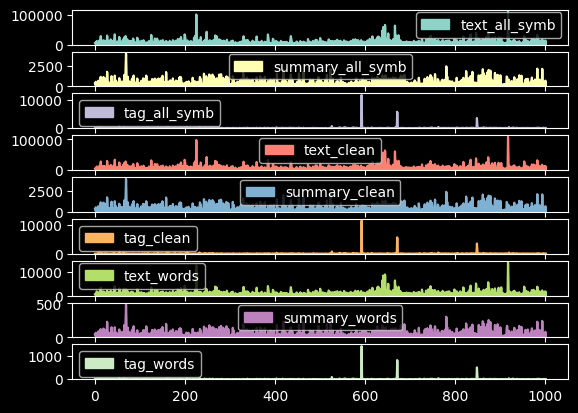

In [9]:
# визуализирую каждую числовую колонку
df_baseline.plot(kind='area', subplots=True)

Можно заметить на графике, что в колонках связанными с `тэгами` есть 3 сильно выраженных столбца (`выбросы`), а также остальные графики выглядят довольно разреженно и `не нормализованно`

In [10]:
# вывожу описание числовых колонок датафрейма
df_baseline.describe()

,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words
count,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000,1002.000000
mean,9243.906188,494.934132,118.254491,8970.108782,485.199601,112.265469,1151.152695,58.764471,12.395210
std,8165.170347,390.030148,426.569564,7920.992738,382.093134,415.891918,1025.736130,46.548680,53.683792
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5049.000000,243.000000,57.000000,4905.250000,240.000000,53.000000,638.250000,29.000000,6.000000
50%,7259.500000,380.500000,85.000000,7041.000000,374.000000,79.500000,898.500000,45.000000,8.000000
75%,10678.750000,606.000000,120.000000,10412.750000,593.000000,114.000000,1331.000000,72.000000,12.000000
max,111644.000000,4082.000000,11641.000000,108116.000000,4007.000000,11354.000000,14220.000000,488.000000,1405.000000


**Из таблицы выше, можно сделать следующие выводы:**

- в файлах со статьями, изложениями и тегами есть пропуски (`min: 0.00`)
- следует поставить пороговые значения для размера статей и изложенией, так как у статей - `max: 111644` символов, при среднем - `9243` символов; у изложений - `max: 4082` символов, при среднем - `494` символов

Реализую фильтрацию, используя функцию `df_filter` из `function`:


In [11]:
# логирование
print(f'Размер датасета до: {df_baseline.shape}')
# копируем датасет
df_main = df_baseline.copy(deep=True)
# проходимся по каждой колонке в датафрейме
for column in df_main.columns:
    # проверяем тип данных в таблице
    if df_main[column].dtype == 'int64':
        # фильтруем колонку, используя df_filter
        df_main = df_filter(df_main, column)
# логирование
print(f'Размер датасета после: {df_main.shape}')
df_main.head()

Размер датасета до: (1002, 16)
Размер датасета после: (412, 16)


,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100
3,../Data/DATASET\1000\text.txt,../Data/DATASET\1000\annotation.txt,../Data/DATASET\1000\tags.txt,Разница между ASP.NET и PHP\nASP.NET - это сер...,В статье описана разница между серверной веб-п...,"ASP.NET, PHP, РАЗЛИЧИЯ, DIFFERENCES",5525,172,35,5356,166,31,710,21,4,1000
5,../Data/DATASET\1002\text.txt,../Data/DATASET\1002\annotation.txt,../Data/DATASET\1002\tags.txt,При разработке веб-сайта перед любым разработч...,В данной статье представлен метод разработки в...,"ПРОГРАММИРОВАНИЕ, ВЕБ-ПРОГРАММИРОВАНИЕ, БАЗА Д...",6776,301,107,6580,295,99,867,38,11,1002


После этого, еще раз выведу графики по каждой числовой колонке, чтобы увидеть как фильтрация нормализовала мой набор данных:

,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words
count,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000,412.000000
mean,7569.475728,403.148058,86.716019,7347.720874,395.873786,81.609223,938.662621,47.439320,8.449029
std,2457.748414,158.165133,30.093276,2406.313019,155.269889,28.696842,295.718820,18.649507,2.788545
min,3452.000000,165.000000,32.000000,3352.000000,162.000000,31.000000,490.000000,21.000000,4.000000
25%,5611.750000,281.000000,63.750000,5398.750000,276.500000,59.750000,703.250000,32.000000,6.000000
50%,7237.000000,372.000000,83.000000,6924.500000,366.000000,78.500000,876.000000,44.000000,8.000000
75%,8985.250000,495.000000,108.000000,8774.500000,485.000000,102.000000,1122.500000,58.000000,10.000000
max,15207.000000,924.000000,166.000000,14695.000000,911.000000,153.000000,1726.000000,101.000000,15.000000


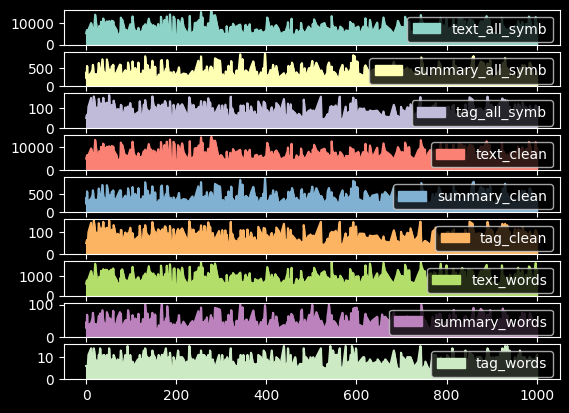

In [12]:
# вывожу график по каждой числовой колонке
df_main.plot(kind='area', subplots=True)
# вывоже описание числовых колонок датафрейма
df_main.describe()

Теперь набор данных нормально распределен, и можно начинать с ним работать

## Предобработка данных

### Лемматизация

При обработке естественного языка требуется предварительная подготовка статей, и одним из способов является **`лемматизация`** – приведение всех слов текста к их нормальным формам с учетом контекста

Для обработки я буду использовать библиотеку `PyMystem3` - библиотека от `Яндекса`, с помощью которой можно реализовать `лемматизацию`

Для начала, нужно инициализировать сам оператор:

In [13]:
# инициализируем оператор mystem
mystem = Mystem()

Installing mystem to C:\Users\alzot/.local/bin\mystem.exe from http://download.cdn.yandex.net/mystem/mystem-3.1-win-64bit.zip


Я буду использовать функции `clean_text` и `text_lemmatize` из модуля `function`, описанные выше

*Пример использования:*

In [14]:
print(text_lemmatize('мама мыла раму', mystem))

мама мыть рама



Видно, что функция работает, и можно приступать к `лемматизации` всего текста

Из-за особенностей работы `PyMystem3`, чтобы обработка датасета не заняла слишком много времени, для начала надо объединить все тексты из датасета в 1, используя какой то уникальный разделитель *(в моем случае - 10101011)*

In [15]:
# объединяем тексты с разделителем "10101011"
combined_text = "10101011".join(df_main['text'])
# выводим общее колво символов в объединённом тексте
print(len(combined_text))

3121912


После того, как я получил объединенный текст, я могу прогнать его через функции `лемматизации` и удаления `стоп-слов`

In [16]:
# обрабатываем объединенный текст
clean_combined = text_lemmatize(clean_text(combined_text, stop_words), mystem)

Вывод кол-ва символов в обработанном тексте:

In [17]:
len(clean_combined)

2787165

После этого, я обратно разделю общий текст используя разделитель (`10101011`), и загружу их в датафрейм в новую колонку `'processed_text'`:

In [18]:
# создаю список с отдельными текстами
processed_texts = clean_combined.split('10101011')
# вывожу кол-во текстов:
print(len(processed_texts))

# создаю новую колонку в датафрейме, 
# и передаю в нее обработанные текста
df_main['processed_text'] = processed_texts
# вывожу получившуюся колонку
df_main['processed_text'].head()

412


0    важный вопрос организация обучение являться со...
1    Фреймворк - это набор концептуальный структура...
2    В современный мир цифровой трансформация стано...
3    Разница ASP.NET PHP ASP.NET - это серверный ве...
5    При разработка веб-сайт любой разработчик возн...
Name: processed_text, dtype: object

Теперь можно сохранить получившийся датафрейм в файл `.csv` формата

In [19]:
# сохраняем датафрейм
df_main.to_csv('final_dataframe.csv', index=False)
df_main.columns

Index(['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag',
       'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean',
       'summary_clean', 'tag_clean', 'text_words', 'summary_words',
       'tag_words', 'id', 'processed_text'],
      dtype='object')

### Разбиение на выборки

Для того чтобы корректно обучить модель, и иметь возможность провалидировать ее на других данных, надо разбить датафрейм на `тренировочную`, `тестовую` и `валидационную` выборки

Для этого, сначала я создам список словарей со всеми элементами датафрейма:

In [20]:
# получаю сохраненный датасет
df = pd.read_csv('final_dataframe.csv', low_memory=False)
# вывожу первые 3 строки
df.head(3)

,text_path,annotation_path,tags_path,text,summary,tag,text_all_symb,summary_all_symb,tag_all_symb,text_clean,summary_clean,tag_clean,text_words,summary_words,tag_words,id,processed_text
0,../Data/DATASET\1\text.txt,../Data/DATASET\1\annotation.txt,../Data/DATASET\1\tags.txt,Важнейшим вопросом для организации обучения яв...,В электронном учебнике изложены основные разде...,"БАЗА ДАННЫХ, MACROMEDIA FLASH, LIBRARY, ACTION...",5160,379,52,5061,374,49,620,45,6,1,важный вопрос организация обучение являться со...
1,../Data/DATASET\10\text.txt,../Data/DATASET\10\annotation.txt,../Data/DATASET\10\tags.txt,Фреймворк - это набор концептуальной структуры...,В этой статье рассматривается Laravel - PHP-фр...,"РАЗРАБОТКА, BACK-END РАЗРАБОТКА, ЗАПРОСЫ, СЕРВ...",6075,212,62,5917,205,58,745,27,6,10,Фреймворк - это набор концептуальный структура...
2,../Data/DATASET\100\text.txt,../Data/DATASET\100\annotation.txt,../Data/DATASET\100\tags.txt,В современном мире цифровая трансформация стал...,Тема финансовой кибербезопасности в условиях ц...,"ФИШИНГ, КИБЕРБЕЗОПАСНОСТЬ, ЦИФРОВЫЕ ТЕХНОЛОГИИ...",6692,569,67,6586,564,64,794,69,6,100,В современный мир цифровой трансформация стано...


In [21]:
# создаем словарь всех элементов датафрейма
samples = df_main.to_dict('records')
# выводим получившийся объект (первый элемент)
samples[0]

{'text_path': '../Data/DATASET\\1\\text.txt',
 'annotation_path': '../Data/DATASET\\1\\annotation.txt',
 'tags_path': '../Data/DATASET\\1\\tags.txt',
 'text': 'Важнейшим вопросом для организации обучения является создание\nэлектронных учебников и внедрение их в учебный процесс. Несмотря на большое\nколичество общедоступных электронных учебников, существует необходимость\nсоздании учебно-методической базы опираясь на рабочие учебные планы конкретного\nуниверситета. Разработки должны опираться на общие правила создания электронных\nучебников, стандартизацию их структуры, внешнего вида и содержания. Технические\nсистемы и технологические процессы, с которыми приходится иметь дело\nсовременным инженерам, отличаются сложностью формального описания,\nобъёмностью и динамичностью.\nВ связи с этой спецификой дистанционного технического образования, базовым\nсредством описания технических процессов становится применение современных\nмультимедийных средств. Использование в мультимедийных электрон

Теперь, используя `split_dataset` из `function` модуля, я разделю датасет на выборки

In [22]:
# разделяем датасет на выборки
dataset = split_dataset(samples)
# выводим структуру датасета
dataset

DatasetDict({
    train: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text'],
        num_rows: 329
    })
    validation: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text'],
        num_rows: 41
    })
    test: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text'],
        num_rows: 42
    })
})

### Токенизация

После того как я `лемматизировал` текста, и удалил из них стоп слова, нужно их `токенизировать`, для того чтобы обучить модель

Я буду использовать модель использующую `T5` архитектуру, поэтому возьму его `токенизатор`

In [23]:
# имя модели, которую я буду использовать в дальнейшем
model_name = "sarahai/ruT5-base-summarizer"  
# токенизатор
tokenizer = T5Tokenizer.from_pretrained(model_name)

d:\Helper\MLBazyak\chemp\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alzot\.cache\huggingface\hub\models--sarahai--ruT5-base-summarizer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Проверим, как работает загруженный `токенизатор`:

In [24]:
# тестовая токенизация
inputs = tokenizer('В далеком лесу, жил старый мудрый филин')
# выводим результат токенизации
inputs

{'input_ids': [32, 1048, 21, 4210, 3, 1561, 3870, 6809, 146, 4796, 761, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Чтобы понять с каким токенизатором я работаю, декодирую эти входные идентификаторы с помощью функции `convert_ids_to_tokens()`

In [25]:
# декодирую токены
tokenizer.convert_ids_to_tokens(inputs.input_ids)

['▁В',
 '▁далеко',
 'м',
 '▁лесу',
 ',',
 '▁жил',
 '▁старый',
 '▁мудр',
 'ый',
 '▁фи',
 'лин',
 '</s>']

После этого, можно реализовать функцию обработки данных в датасете

In [30]:
#
def preprocess_data(examples):
    #
    inputs = [text for text in examples['processed_text']]
    #
    targets = [summary for summary in examples['summary']]

    # токенизация с паддингом
    model_inputs = tokenizer(
        inputs,
        max_length=512,        # максимальная длина текста
        truncation=True,       # обрезать тексты длиннее max_length
        padding='max_length',  # дополнять тексты до max_length
        return_tensors='pt'    # возвращать тензоры PyTorch
    )

    # токенизация таргета (summary)
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets,                
            max_length=128,         # максимальная длина суммаризации
            truncation=True,        # обрезать длиннее чем 128 токенов
            padding='max_length',   # дополять суммаризацию
            return_tensors='pt'     # возвращать тензоры PyTorch
        )

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

In [31]:
tokenized_datasets = dataset.map(preprocess_data, batched=True)

Map: 100%|██████████| 42/42 [00:00<00:00, 70.76 examples/s]


In [32]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 329
    })
    validation: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 41
    })
    test: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 

Сохранение полученного датасета:

In [34]:
# Сохраняем train, validation и test в отдельные CSV файлы
tokenized_datasets["train"].to_csv("Dataset/train.csv")
tokenized_datasets["validation"].to_csv("Dataset/validation.csv")
tokenized_datasets["test"].to_csv("Dataset/test.csv")

Creating CSV from Arrow format: 100%|██████████| 1/1 [00:00<00:00,  6.92ba/s]


1308513

In [35]:
train_dataset = Dataset.from_csv("Dataset/train.csv")
validation_dataset = Dataset.from_csv("Dataset/validation.csv")
test_dataset = Dataset.from_csv("Dataset/test.csv")

loaded_dataset = DatasetDict({
    "train": train_dataset,
    "validation": validation_dataset,
    "test": test_dataset
})
loaded_dataset

Generating train split: 329 examples [00:00, 918.02 examples/s]
Generating train split: 41 examples [00:00, 636.31 examples/s]
Generating train split: 42 examples [00:00, 754.74 examples/s]


DatasetDict({
    train: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 329
    })
    validation: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 'attention_mask', 'labels'],
        num_rows: 41
    })
    test: Dataset({
        features: ['text_path', 'annotation_path', 'tags_path', 'text', 'summary', 'tag', 'text_all_symb', 'summary_all_symb', 'tag_all_symb', 'text_clean', 'summary_clean', 'tag_clean', 'text_words', 'summary_words', 'tag_words', 'id', 'processed_text', 'input_ids', 